In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
df.drop(columns=["id", "Unnamed: 32"], errors="ignore", inplace=True)
print(f"  Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df.head(3))

  Rows: 569, Columns: 31
  diagnosis  radius_mean  ...  symmetry_worst  fractal_dimension_worst
0         M        17.99  ...          0.4601                  0.11890
1         M        20.57  ...          0.2750                  0.08902
2         M        19.69  ...          0.3613                  0.08758

[3 rows x 31 columns]


In [4]:
print("\nSTEP 2: Exploring data...")
print("  Missing values:", df.isnull().sum().sum())
print("  Class counts:\n", df["diagnosis"].value_counts())


STEP 2: Exploring data...
  Missing values: 0
  Class counts:
 diagnosis
B    357
M    212
Name: count, dtype: int64


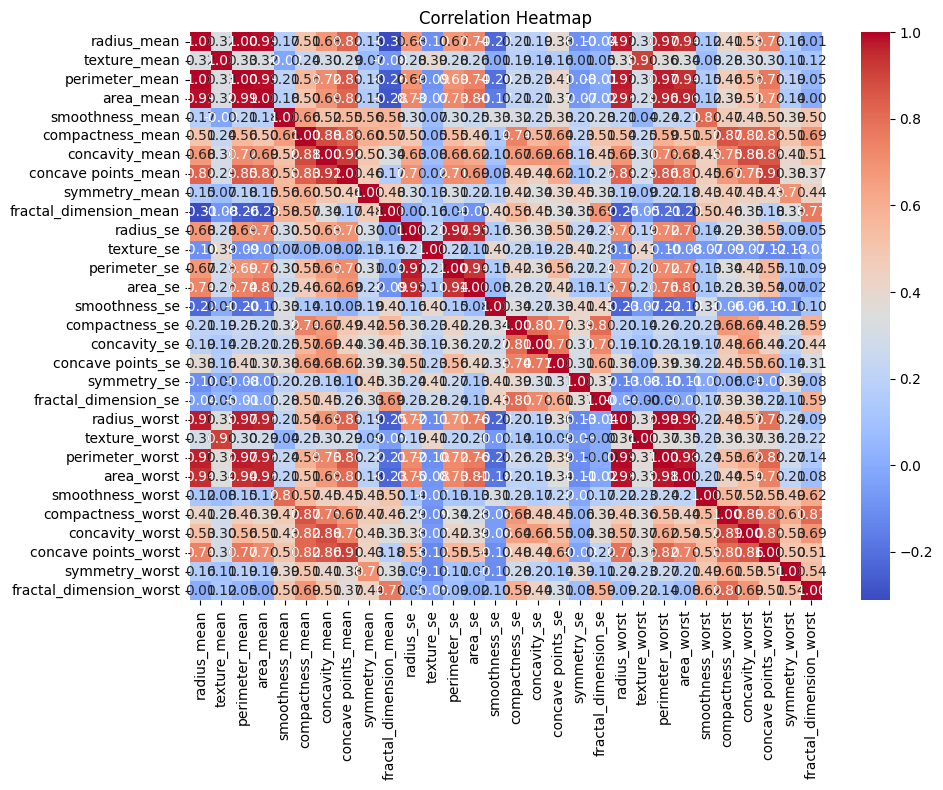


  Logistic Regression: 97.37% accuracy
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



<Figure size 600x400 with 0 Axes>

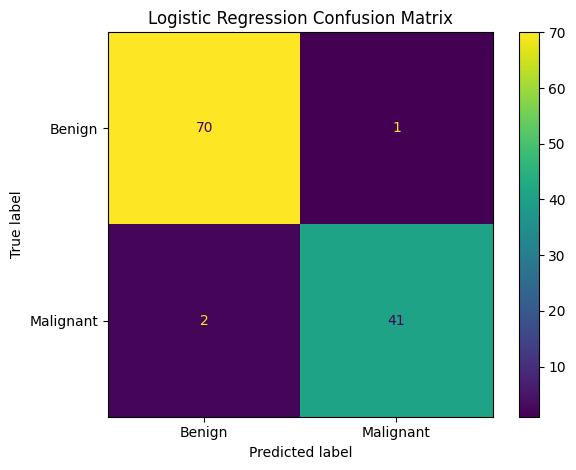


  Top 10 Important Features for Logistic Regression:
             Feature  Importance
       texture_worst    1.350606
           radius_se    1.268178
      symmetry_worst    1.208200
 concave points_mean    1.119804
     concavity_worst    0.943053
             area_se    0.907186
        radius_worst    0.879840
          area_worst    0.841846
      concavity_mean    0.801458
concave points_worst    0.778217


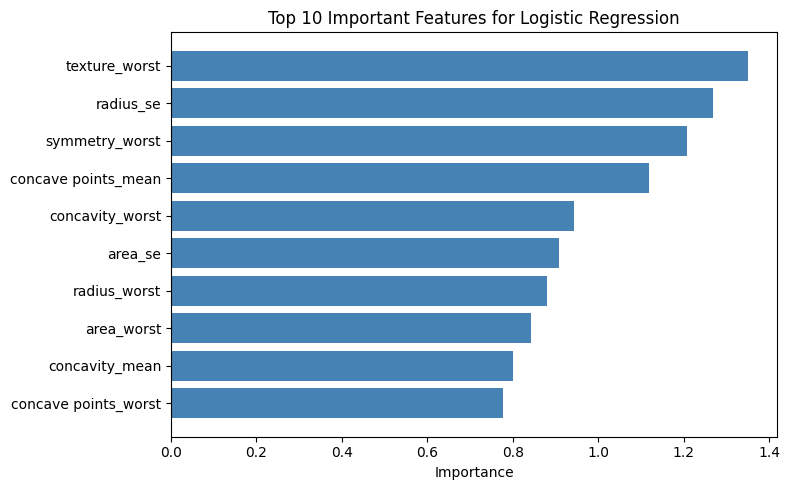


  Random Forest: 96.49% accuracy
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        71
   Malignant       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



<Figure size 600x400 with 0 Axes>

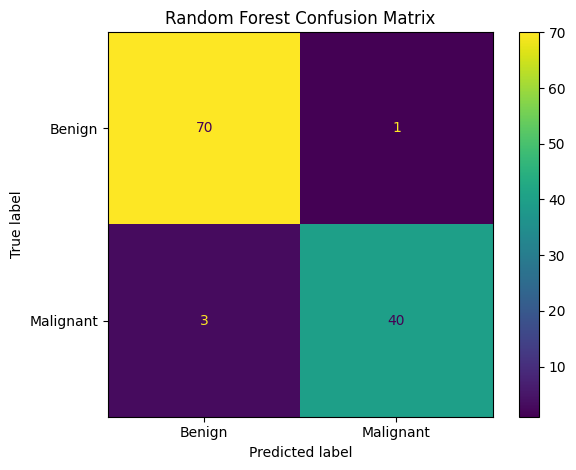


  Top 10 Important Features for Random Forest:
             Feature  Importance
          area_worst    0.153892
concave points_worst    0.144663
 concave points_mean    0.106210
        radius_worst    0.077987
      concavity_mean    0.068001
     perimeter_worst    0.067115
      perimeter_mean    0.053270
         radius_mean    0.048703
           area_mean    0.047555
     concavity_worst    0.031802


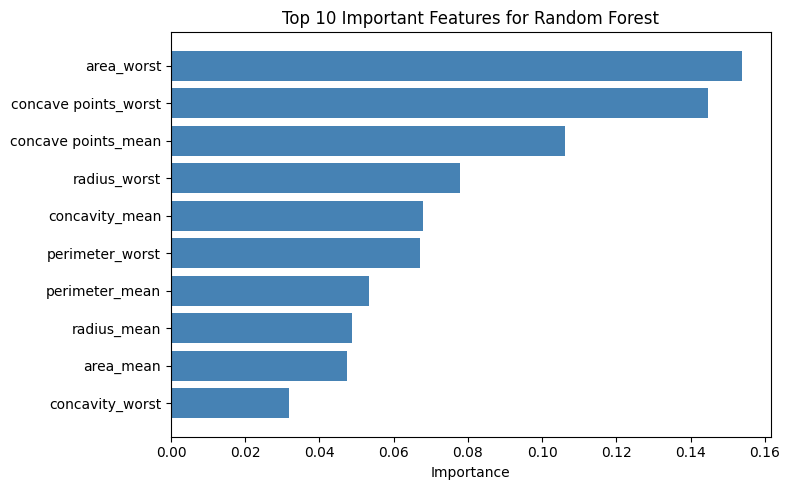


  Sample Prediction:
  Logistic Regression: BENIGN  (Benign=87.1%, Malignant=12.9%)
  Random Forest: BENIGN  (Benign=85.0%, Malignant=15.0%)

  Final Model Accuracies on Test Set:
  Logistic Regression: 97.37%
  Random Forest: 96.49%


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix,ConfusionMatrixDisplay


def ml_pipeline(filepath):
  df=pd.read_csv('/content/data.csv')
  df.drop(columns=['id','Unnamed: 32'] , errors='ignore',inplace=True)

  plt.figure(figsize=(5,4))
  df['diagnosis'].value_counts().plot(kind='bar', color=['red','green'])
  plt.title("Benign vs Malignant")
  plt.xlabel("Diagnosis")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.close()

  plt.figure(figsize=(10,8))
  sns.heatmap(df.drop(columns=['diagnosis']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
  plt.title("Correlation Heatmap")
  plt.tight_layout()
  plt.show()
  plt.close()

  df['target']=df['diagnosis'].map({'M':1,'B':0})
  X=df.drop(columns=['diagnosis','target'])
  y=df['target']


  X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

  scaler=StandardScaler()
  X_train=scaler.fit_transform(X_train)
  X_test=scaler.transform(X_test)

  model1=LogisticRegression(random_state=42)
  model1.fit(X_train,y_train)

  model2=RandomForestClassifier(random_state=42)
  model2.fit(X_train,y_train)

  for name,model in [('Logistic Regression',model1),('Random Forest',model2)]:
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    print(f"\n  {name}: {acc * 100:.2f}% accuracy")
    print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))


    plt.figure(figsize=(6, 4))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm,display_labels=['Benign','Malignant']).plot()
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    plt.close()


    feature_names=X.columns
    if isinstance(model, LogisticRegression):

        importances = np.abs(model.coef_[0])
    elif isinstance(model, RandomForestClassifier):

        importances = model.feature_importances_
    else:
        importances = np.zeros(len(feature_names))

    feat_df=pd.DataFrame({'Feature':feature_names,'Importance':importances})
    feat_df=feat_df.sort_values('Importance',ascending=False).head(10)
    print(f"\n  Top 10 Important Features for {name}:")
    print(feat_df.to_string(index=False))

    plt.figure(figsize=(8, 5))
    plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color="steelblue")
    plt.title(f"Top 10 Important Features for {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    plt.close()

  sample = X_train[0].reshape(1, -1)

  print("\n  Sample Prediction:")
  for name, model in [("Logistic Regression", model1), ("Random Forest", model2)]:
      result     = model.predict(sample)[0]
      confidence = model.predict_proba(sample)[0]
      label      = "MALIGNANT" if result == 1 else "BENIGN"
      print(f"  {name}: {label}  (Benign={confidence[0]*100:.1f}%, Malignant={confidence[1]*100:.1f}%)")

  print("\n  Final Model Accuracies on Test Set:")
  for name, model in [("Logistic Regression", model1), ("Random Forest", model2)]:
      acc = accuracy_score(y_test, model.predict(X_test))
      print(f"  {name}: {acc * 100:.2f}%")

ml_pipeline("/content/data.csv")